

All BraTS multimodal scans are available as NIfTI files (.nii.gz) -> commonly used medical imaging format to store brain image data obtained using MRI and describe different MRI settings

T1: T1-weighted, native image, sagittal or axial 2D acquisitions, with 1–6 mm slice thickness.
T1c: T1-weighted, contrast-enhanced (Gadolinium) image, with 3D acquisition and 1 mm isotropic voxel size for most patients.
T2: T2-weighted image, axial 2D acquisition, with 2–6 mm slice thickness.
FLAIR: T2-weighted FLAIR image, axial, coronal, or sagittal 2D acquisitions, 2–6 mm slice thickness.
1) Load sample images and visualize
2) Includes, dividing each image by its max to scale them to [0,1]
3) Converting mask from float to uint8
4) Changing mask pixel values (labels) from 4 to 3 (as the original labels are 0, 1, 2, 4)
5) Visualize

6) View a few images

Note: Segmented file name in Folder 355 has a weird name. So we have to rename it Rename it to match others.

In [1]:
# Importing Library

import os
import glob
import random
import numpy as np
import nibabel as nib
import cv2
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

2026-04-13 17:26:32.667958: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776101193.042449      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776101193.151717      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776101194.012821      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776101194.012877      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776101194.012907      55 computation_placer.cc:177] computation placer alr

In [2]:
# Datasets Paths 
TRAIN_BASE = "/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData"
TEST_BASE  = "/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_ValidationData/MICCAI_BraTS2020_ValidationData"

In [3]:
# Get only folders (not files)
folders = [f for f in os.listdir(TRAIN_BASE) if os.path.isdir(os.path.join(TRAIN_BASE, f))]

random.seed(42)
random.shuffle(folders)

split = int(0.8 * len(folders))
train_folders = folders[:split]
val_folders   = folders[split:]

print(f"Train folders: {len(train_folders)}")
print(f"Val   folders: {len(val_folders)}")

Train folders: 295
Val   folders: 74


In [4]:
# Preprocessing Functions 

def normalize_volume(img):
    """
    Normalize a 3D volume to [0, 1] using min-max scaling.
    Handles zero-volume edge case with epsilon.
    """
    img = img.astype(np.float32)
    mn  = np.min(img)
    mx  = np.max(img)
    return (img - mn) / (mx - mn + 1e-8)


def load_case(folder_path):
    """
    All 4 modalities are now normalized consistently.
    """
    t1_path    = glob.glob(folder_path + "/*t1.nii")[0]
    t2_path    = glob.glob(folder_path + "/*t2.nii")[0]
    flair_path = glob.glob(folder_path + "/*flair.nii")[0]
    t1ce_path  = glob.glob(folder_path + "/*t1ce.nii")[0]

    # Handle edge-case folder 355 (weird seg file name)
    mask_paths = glob.glob(folder_path + "/*seg*.nii") or \
                 glob.glob(folder_path + "/*Segm*.nii")
    mask_path  = mask_paths[0]

    # Load volumes
    t1    = nib.load(t1_path).get_fdata()
    t2    = nib.load(t2_path).get_fdata()
    flair = nib.load(flair_path).get_fdata()
    t1ce  = nib.load(t1ce_path).get_fdata()
    mask  = nib.load(mask_path).get_fdata()

    # Normalize ALL 4 modalities (was: only T1 normalized before)
    t1    = normalize_volume(t1)
    t2    = normalize_volume(t2)
    flair = normalize_volume(flair)
    t1ce  = normalize_volume(t1ce)

    # Convert mask and remap label 4 - 3
    mask = mask.astype(np.uint8)
    mask[mask == 4] = 3

    return t1, t2, flair, t1ce, mask


def create_multichannel(t1, t2, flair, t1ce):
    """Stack 4 modalities → shape (H, W, D, 4)."""
    return np.stack([t1, t2, flair, t1ce], axis=3)


def crop_volume(img, mask):
    """
    Crop to (128, 128, 128) brain ROI to remove empty borders.
    img  shape: (240, 240, 155, 4) → (128, 128, 128, 4)
    mask shape: (240, 240, 155)    → (128, 128, 128)
    """
    img  = img[56:184, 56:184, 13:141, :]
    mask = mask[56:184, 56:184, 13:141]
    return img, mask


def create_2d_slices(img, mask, tumor_threshold=0.01):
    """
    FIX #2: Apply same tumor-slice filtering to BOTH train AND val.
    Only keep slices where tumor pixels > threshold (default 1%).
    img  shape: (H, W, D, 4)
    mask shape: (H, W, D)
    Returns lists of 2D slices.
    """
    X, Y = [], []

    for i in range(img.shape[2]):
        img_slice  = img[:, :, i, :]    # (128, 128, 4)
        mask_slice = mask[:, :, i]       # (128, 128)

        # Count non-background pixels
        n_tumor = np.sum(mask_slice > 0)
        n_total = mask_slice.size

        # Skip nearly-empty slices (background > 99%)
        if n_tumor / n_total < tumor_threshold:
            continue

        X.append(img_slice)
        Y.append(mask_slice)

    return X, Y


def resize_slices(X, Y, target_size=(128, 128)):
    """
    Resize all slices to target size.
    Uses INTER_NEAREST for masks to avoid label interpolation artifacts.
    """
    X_resized = []
    Y_resized = []

    for i in range(len(X)):
        img  = cv2.resize(X[i], target_size)                                   # bilinear for image
        msk  = cv2.resize(Y[i], target_size, interpolation=cv2.INTER_NEAREST)  # nearest for mask
        X_resized.append(img)
        Y_resized.append(msk)

    return np.array(X_resized, dtype=np.float32), np.array(Y_resized, dtype=np.uint8)

In [5]:
# Build Training Dataset
# We can increase to all 295 for best results (more GPU time required).
N_TRAIN = 80   # increase to len(train_folders) for full training
N_VAL   = 30   # increase to len(val_folders)   for full validation

print(f"\nBuilding training set from {N_TRAIN} folders...")

X_train_list = []
Y_train_list = []

for idx, folder in enumerate(train_folders[:N_TRAIN]):
    folder_path = os.path.join(TRAIN_BASE, folder)

    try:
        t1, t2, flair, t1ce, mask = load_case(folder_path)
    except Exception as e:
        print(f"  Skipping {folder}: {e}")
        continue

    img = create_multichannel(t1, t2, flair, t1ce)
    img, mask = crop_volume(img, mask)

    x_slices, y_slices = create_2d_slices(img, mask, tumor_threshold=0.01)

    if len(x_slices) == 0:
        print(f"  Skipping {folder}: no tumor slices after filtering")
        continue

    x_arr, y_arr = resize_slices(x_slices, y_slices)

    X_train_list.append(x_arr)
    Y_train_list.append(y_arr)

    if (idx + 1) % 10 == 0:
        print(f"  Processed {idx + 1}/{N_TRAIN} folders")

X_train = np.concatenate(X_train_list, axis=0)
Y_train = np.concatenate(Y_train_list, axis=0)

# Safety check — remap any stray label-4 pixels
Y_train[Y_train == 4] = 3
assert Y_train.max() <= 3, f"Unexpected label: {Y_train.max()}"

# One-hot encode masks: (N, 128, 128)--- (N, 128, 128, 4)
Y_train_cat = to_categorical(Y_train, num_classes=4).astype(np.float32)

print(f"\nX_train shape : {X_train.shape}")
print(f"Y_train shape : {Y_train_cat.shape}")

# ---- Class distribution ----
unique, counts = np.unique(Y_train, return_counts=True)
total = Y_train.size
print("\nClass distribution (training):")
for u, c in zip(unique, counts):
    print(f"  Class {u}: {c:,} pixels  ({100*c/total:.2f}%)")



Building training set from 80 folders...
  Processed 10/80 folders
  Processed 20/80 folders
  Processed 30/80 folders
  Processed 40/80 folders
  Processed 50/80 folders
  Processed 60/80 folders
  Processed 70/80 folders
  Processed 80/80 folders

X_train shape : (4572, 128, 128, 4)
Y_train shape : (4572, 128, 128, 4)

Class distribution (training):
  Class 0: 67,099,360 pixels  (89.58%)
  Class 1: 1,483,518 pixels  (1.98%)
  Class 2: 4,802,547 pixels  (6.41%)
  Class 3: 1,522,223 pixels  (2.03%)


In [6]:

# Build Validation Dataset
print(f"\nBuilding validation set from {N_VAL} folders...")

X_val_list = []
Y_val_list = []

for idx, folder in enumerate(val_folders[:N_VAL]):
    folder_path = os.path.join(TRAIN_BASE, folder)

    try:
        t1, t2, flair, t1ce, mask = load_case(folder_path)
    except Exception as e:
        print(f"  Skipping {folder}: {e}")
        continue

    img = create_multichannel(t1, t2, flair, t1ce)
    img, mask = crop_volume(img, mask)
    x_slices, y_slices = create_2d_slices(img, mask, tumor_threshold=0.01)

    if len(x_slices) == 0:
        print(f"  Skipping {folder}: no tumor slices after filtering")
        continue

    x_arr, y_arr = resize_slices(x_slices, y_slices)

    X_val_list.append(x_arr)
    Y_val_list.append(y_arr)

X_val = np.concatenate(X_val_list, axis=0)
Y_val = np.concatenate(Y_val_list, axis=0)

Y_val[Y_val == 4] = 3
assert Y_val.max() <= 3, f"Unexpected label: {Y_val.max()}"

Y_val_cat = to_categorical(Y_val, num_classes=4).astype(np.float32)

print(f"X_val shape : {X_val.shape}")
print(f"Y_val shape : {Y_val_cat.shape}")


Building validation set from 30 folders...
X_val shape : (1865, 128, 128, 4)
Y_val shape : (1865, 128, 128, 4)


In [7]:
# Computing Class Weights 
unique, counts = np.unique(Y_train, return_counts=True)
n_samples = Y_train.size
n_classes = 4

# Inverse-frequency weighting
class_weight = {}
for u, c in zip(unique, counts):
    class_weight[int(u)] = n_samples / (n_classes * c)

print("\nClass weights:")
for k, v in class_weight.items():
    print(f"  Class {k}: {v:.4f}")


Class weights:
  Class 0: 0.2791
  Class 1: 12.6233
  Class 2: 3.8994
  Class 3: 12.3023


In [8]:
# Building U-Net with BatchNorm + Dropout 

def conv_block(x, filters, dropout_rate=0.2):
    """Two Conv2D + BN + ReLU + Dropout block."""
    x = layers.Conv2D(filters, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)      
    x = layers.Activation('relu')(x)
    x = layers.Dropout(dropout_rate)(x)     
    x = layers.Conv2D(filters, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    return x


def build_unet(input_shape=(128, 128, 4), num_classes=4):
    """
    U-Net with:
      - BatchNormalization after every Conv2D  
      - Dropout in encoder blocks              
      - Softmax output for multi-class seg
    """
    inputs = layers.Input(input_shape)

    # ---- Encoder ----
    c1 = conv_block(inputs, 64)
    p1 = layers.MaxPooling2D()(c1)

    c2 = conv_block(p1, 128)
    p2 = layers.MaxPooling2D()(c2)

    c3 = conv_block(p2, 256)
    p3 = layers.MaxPooling2D()(c3)

    # ---- Bottleneck ----
    b  = conv_block(p3, 512, dropout_rate=0.3)

    # ---- Decoder ----
    u1 = layers.UpSampling2D()(b)
    u1 = layers.concatenate([u1, c3])
    c4 = conv_block(u1, 256)

    u2 = layers.UpSampling2D()(c4)
    u2 = layers.concatenate([u2, c2])
    c5 = conv_block(u2, 128)

    u3 = layers.UpSampling2D()(c5)
    u3 = layers.concatenate([u3, c1])
    c6 = conv_block(u3, 64)

    outputs = layers.Conv2D(num_classes, 1, activation='softmax')(c6)

    model = models.Model(inputs, outputs, name='UNet_BraTS')
    return model


model = build_unet()
model.summary()


I0000 00:00:1776101417.520729      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "UNet_BraTS"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │      2,368 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128, 128,  │          0 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │     36,928 │ dropout[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64, 64,    │          0 │ activation_2[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │    147,584 │ dropout_1[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ activation_3[0][

 Total params: 7,794,948 (29.74 MB)

 Trainable params: 7,789,316 (29.71 MB)

 Non-trainable params: 5,632 (22.00 KB)

In [9]:
# Loss and Metric Functions 

def dice_coef(y_true, y_pred, smooth=1e-6):
    """
    Mean Dice coefficient over all classes including background.
    Operates on one-hot encoded tensors.
    """
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    intersection = tf.reduce_sum(y_true * y_pred, axis=[1, 2])
    union        = tf.reduce_sum(y_true, axis=[1, 2]) + tf.reduce_sum(y_pred, axis=[1, 2])
    dice         = (2.0 * intersection + smooth) / (union + smooth)

    return tf.reduce_mean(dice)


def dice_coef_tumor(y_true, y_pred, smooth=1e-6):
    """
    Dice coefficient averaged over TUMOR classes only (1, 2, 3).
    This is the clinically meaningful metric for BraTS.
    """
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    # Channels 1, 2, 3 = tumor classes; 0 = background
    y_true_tumor = y_true[:, :, :, 1:]
    y_pred_tumor = y_pred[:, :, :, 1:]

    intersection = tf.reduce_sum(y_true * y_pred, axis=[1, 2, 3])
    union = tf.reduce_sum(y_true, axis=[1, 2, 3]) + tf.reduce_sum(y_pred, axis=[1, 2, 3])
    dice         = (2.0 * intersection + smooth) / (union + smooth)

    return tf.reduce_mean(dice)


def dice_loss(y_true, y_pred):
    """Dice loss = 1 - mean Dice (over all classes)."""
    return 1.0 - dice_coef(y_true, y_pred)


def combined_loss(y_true, y_pred):
    """
    Combined = 0.5 * Dice Loss + 0.5 * Categorical Cross-Entropy.
    More stable training than pure Dice especially early on.
    """
    d_loss  = dice_loss(y_true, y_pred)
    ce_loss = tf.keras.losses.categorical_crossentropy(y_true, y_pred)
    ce_loss = tf.reduce_mean(ce_loss)
    return 0.5 * d_loss + 0.5 * ce_loss


In [10]:
# Compile Model

# Build weighted loss using class_weight dict computed in Cell 6
w_tensor = tf.constant([class_weight[i] for i in range(4)], dtype=tf.float32)

def weighted_combined_loss(class_weights_tensor):
    def loss(y_true, y_pred):
        weights = tf.reduce_sum(class_weights_tensor * y_true, axis=-1)  # (B, H, W)
        d_loss  = dice_loss(y_true, y_pred)
        ce      = tf.keras.losses.categorical_crossentropy(y_true, y_pred)
        return tf.reduce_mean(weights * ce) * 0.5 + d_loss * 0.5
    return loss

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=weighted_combined_loss(w_tensor),         # replaces combined_loss
    metrics=[dice_coef, dice_coef_tumor]
)

print("Model compiled with Weighted Combined (Dice + CE) loss")

Model compiled with Weighted Combined (Dice + CE) loss


In [11]:
# Callbacks (EarlyStopping actually passed to fit)

callbacks = [
    EarlyStopping(
        monitor='val_dice_coef_tumor',
        patience=10,
        mode='max',
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath='best_unet_brats.h5',
        monitor='val_dice_coef_tumor',
        mode='max',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_dice_coef_tumor',
        factor=0.5,
        patience=5,
        mode='max',
        min_lr=1e-7,
        verbose=1
    )
]

In [12]:
# Train

history = model.fit(
    X_train, Y_train_cat,
    validation_data=(X_val, Y_val_cat),
    epochs=60,
    batch_size=8,                   # Slightly larger batch for stability
    callbacks=callbacks,         
    shuffle=True
)

print("\nTraining complete")


Epoch 1/60


I0000 00:00:1776101434.951598     124 service.cc:152] XLA service 0x78111c003670 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776101434.951656     124 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1776101436.902236     124 cuda_dnn.cc:529] Loaded cuDNN version 91002


  3/572 ━━━━━━━━━━━━━━━━━━━━ 35s 63ms/step - dice_coef: 0.1281 - dice_coef_tumor: 0.2250 - loss: 1.2195  

I0000 00:00:1776101454.836542     124 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


571/572 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - dice_coef: 0.2903 - dice_coef_tumor: 0.5381 - loss: 0.7710

...

572/572 ━━━━━━━━━━━━━━━━━━━━ 38s 66ms/step - dice_coef: 0.7119 - dice_coef_tumor: 0.9758 - loss: 0.2127 - val_dice_coef: 0.6324 - val_dice_coef_tumor: 0.9584 - val_loss: 0.6942 - learning_rate: 5.0000e-05
Epoch 13/60
571/572 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - dice_coef: 0.7109 - dice_coef_tumor: 0.9769 - loss: 0.2107
Epoch 13: val_dice_coef_tumor did not improve from 0.95843
572/572 ━━━━━━━━━━━━━━━━━━━━ 37s 65ms/step - dice_coef: 0.7109 - dice_coef_tumor: 0.9769 - loss: 0.2107 - val_dice_coef: 0.6344 - val_dice_coef_tumor: 0.9562 - val_loss: 0.6740 - learning_rate: 5.0000e-05
Epoch 14/60
571/572 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - dice_coef: 0.7137 - dice_coef_tumor: 0.9777 - loss: 0.2072
Epoch 14: val_dice_coef_tumor did not improve from 0.95843
572/572 ━━━━━━━━━━━━━━━━━━━━ 37s 65ms/step - dice_coef: 0.7137 - dice_coef_tumor: 0.9777 - loss: 0.2072 - val_dice_coef: 0.6277 - val_dice_coef_tumor: 0.9566 - val_loss: 0.7434 - learning_rate: 5.0000e-05
Epoch 15/60
571/572 ━━━━━━━━━━━━━━━━━


Epoch 17: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
572/572 ━━━━━━━━━━━━━━━━━━━━ 38s 66ms/step - dice_coef: 0.7265 - dice_coef_tumor: 0.9791 - loss: 0.1989 - val_dice_coef: 0.6336 - val_dice_coef_tumor: 0.9584 - val_loss: 0.7162 - learning_rate: 5.0000e-05
Epoch 18/60
571/572 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - dice_coef: 0.7297 - dice_coef_tumor: 0.9802 - loss: 0.1940
Epoch 18: val_dice_coef_tumor did not improve from 0.95844
572/572 ━━━━━━━━━━━━━━━━━━━━ 37s 65ms/step - dice_coef: 0.7297 - dice_coef_tumor: 0.9802 - loss: 0.1940 - val_dice_coef: 0.6327 - val_dice_coef_tumor: 0.9572 - val_loss: 0.7255 - learning_rate: 2.5000e-05
Epoch 19/60
571/572 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - dice_coef: 0.7317 - dice_coef_tumor: 0.9805 - loss: 0.1910
Epoch 19: val_dice_coef_tumor improved from 0.95844 to 0.96111, saving model to best_unet_brats.h5


572/572 ━━━━━━━━━━━━━━━━━━━━ 38s 66ms/step - dice_coef: 0.7317 - dice_coef_tumor: 0.9805 - loss: 0.1910 - val_dice_coef: 0.6358 - val_dice_coef_tumor: 0.9611 - val_loss: 0.7658 - learning_rate: 2.5000e-05
Epoch 20/60
571/572 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - dice_coef: 0.7325 - dice_coef_tumor: 0.9811 - loss: 0.1885
Epoch 20: val_dice_coef_tumor did not improve from 0.96111
572/572 ━━━━━━━━━━━━━━━━━━━━ 37s 65ms/step - dice_coef: 0.7325 - dice_coef_tumor: 0.9811 - loss: 0.1885 - val_dice_coef: 0.6306 - val_dice_coef_tumor: 0.9584 - val_loss: 0.7971 - learning_rate: 2.5000e-05
Epoch 21/60
571/572 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - dice_coef: 0.7353 - dice_coef_tumor: 0.9810 - loss: 0.1874
Epoch 21: val_dice_coef_tumor did not improve from 0.96111
572/572 ━━━━━━━━━━━━━━━━━━━━ 37s 65ms/step - dice_coef: 0.7353 - dice_coef_tumor: 0.9810 - loss: 0.1874 - val_dice_coef: 0.6388 - val_dice_coef_tumor: 0.9599 - val_loss: 0.7342 - learning_rate: 2.5000e-05
Epoch 22/60
571/572 ━━━━━━━━━━━━━━━━━

572/572 ━━━━━━━━━━━━━━━━━━━━ 38s 66ms/step - dice_coef: 0.7323 - dice_coef_tumor: 0.9812 - loss: 0.1886 - val_dice_coef: 0.6408 - val_dice_coef_tumor: 0.9612 - val_loss: 0.7442 - learning_rate: 2.5000e-05
Epoch 24/60
571/572 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - dice_coef: 0.7346 - dice_coef_tumor: 0.9811 - loss: 0.1878
Epoch 24: val_dice_coef_tumor improved from 0.96123 to 0.96279, saving model to best_unet_brats.h5


572/572 ━━━━━━━━━━━━━━━━━━━━ 38s 66ms/step - dice_coef: 0.7346 - dice_coef_tumor: 0.9811 - loss: 0.1878 - val_dice_coef: 0.6415 - val_dice_coef_tumor: 0.9628 - val_loss: 0.7615 - learning_rate: 2.5000e-05
Epoch 25/60
571/572 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - dice_coef: 0.7366 - dice_coef_tumor: 0.9818 - loss: 0.1858
Epoch 25: val_dice_coef_tumor did not improve from 0.96279
572/572 ━━━━━━━━━━━━━━━━━━━━ 37s 65ms/step - dice_coef: 0.7366 - dice_coef_tumor: 0.9818 - loss: 0.1858 - val_dice_coef: 0.6427 - val_dice_coef_tumor: 0.9615 - val_loss: 0.7206 - learning_rate: 2.5000e-05
Epoch 26/60
571/572 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - dice_coef: 0.7387 - dice_coef_tumor: 0.9817 - loss: 0.1850
Epoch 26: val_dice_coef_tumor did not improve from 0.96279
572/572 ━━━━━━━━━━━━━━━━━━━━ 37s 65ms/step - dice_coef: 0.7387 - dice_coef_tumor: 0.9817 - loss: 0.1850 - val_dice_coef: 0.6413 - val_dice_coef_tumor: 0.9609 - val_loss: 0.7846 - learning_rate: 2.5000e-05
Epoch 27/60
571/572 ━━━━━━━━━━━━━━━━━

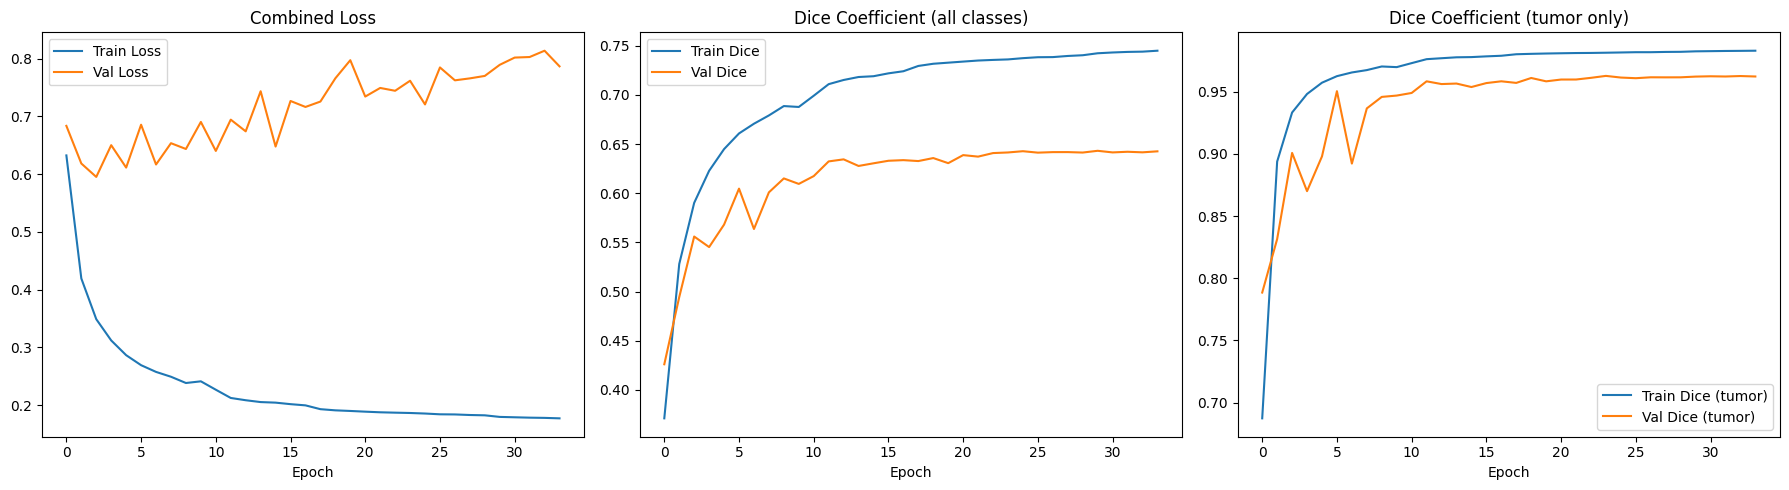

In [13]:
# Plot Training Curves

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(history.history['loss'],          label='Train Loss')
axes[0].plot(history.history['val_loss'],      label='Val Loss')
axes[0].set_title('Combined Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

# Overall Dice
axes[1].plot(history.history['dice_coef'],     label='Train Dice')
axes[1].plot(history.history['val_dice_coef'], label='Val Dice')
axes[1].set_title('Dice Coefficient (all classes)')
axes[1].set_xlabel('Epoch')
axes[1].legend()

# Tumor-only Dice (the real metric)
axes[2].plot(history.history['dice_coef_tumor'],     label='Train Dice (tumor)')
axes[2].plot(history.history['val_dice_coef_tumor'], label='Val Dice (tumor)')
axes[2].set_title('Dice Coefficient (tumor only)')
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

In [14]:
# Evaluate on Validation Set — Print Real Metrics

def compute_metrics_numpy(Y_true_int, Y_pred_int, n_classes=4):
    """
    Compute per-class Dice and IoU from integer label arrays.
    Y_true_int, Y_pred_int: shape (N, H, W), integer labels 0-3
    """
    dice_scores = {}
    iou_scores  = {}

    for cls in range(n_classes):
        tp = np.sum((Y_true_int == cls) & (Y_pred_int == cls))
        fp = np.sum((Y_true_int != cls) & (Y_pred_int == cls))
        fn = np.sum((Y_true_int == cls) & (Y_pred_int != cls))

        dice = (2 * tp + 1e-6) / (2 * tp + fp + fn + 1e-6)
        iou  = (tp + 1e-6)     / (tp + fp + fn + 1e-6)

        dice_scores[cls] = dice
        iou_scores[cls]  = iou

    return dice_scores, iou_scores


# Run predictions on validation set in batches to avoid OOM
BATCH = 32
all_preds = []
for i in range(0, len(X_val), BATCH):
    preds = model.predict(X_val[i:i+BATCH], verbose=0)
    all_preds.append(np.argmax(preds, axis=-1))

Y_pred_int = np.concatenate(all_preds, axis=0)    # (N, 128, 128)
Y_true_int = Y_val                                  # (N, 128, 128) integer

dice_scores, iou_scores = compute_metrics_numpy(Y_true_int, Y_pred_int)

print("\n========== VALIDATION METRICS ==========")
class_names = {0: 'Background', 1: 'NCR/NET', 2: 'Edema', 3: 'ET'}
for cls in range(4):
    print(f"  Class {cls} ({class_names[cls]}):  "
          f"Dice = {dice_scores[cls]:.4f}   IoU = {iou_scores[cls]:.4f}")

# Mean over TUMOR classes only (1, 2, 3)
mean_tumor_dice = np.mean([dice_scores[c] for c in [1, 2, 3]])
mean_tumor_iou  = np.mean([iou_scores[c]  for c in [1, 2, 3]])
print(f"\n  Mean Tumor Dice (classes 1,2,3) : {mean_tumor_dice:.4f}")
print(f"  Mean Tumor IoU  (classes 1,2,3) : {mean_tumor_iou:.4f}")
print("=========================================")

2026-04-13 17:52:47.123067: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-13 17:52:47.370613: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



========== VALIDATION METRICS ==========
  Class 0 (Background):  Dice = 0.9875   IoU = 0.9752
  Class 1 (NCR/NET):  Dice = 0.6640   IoU = 0.4970
  Class 2 (Edema):  Dice = 0.7833   IoU = 0.6438
  Class 3 (ET):  Dice = 0.8501   IoU = 0.7393

  Mean Tumor Dice (classes 1,2,3) : 0.7658
  Mean Tumor IoU  (classes 1,2,3) : 0.6267


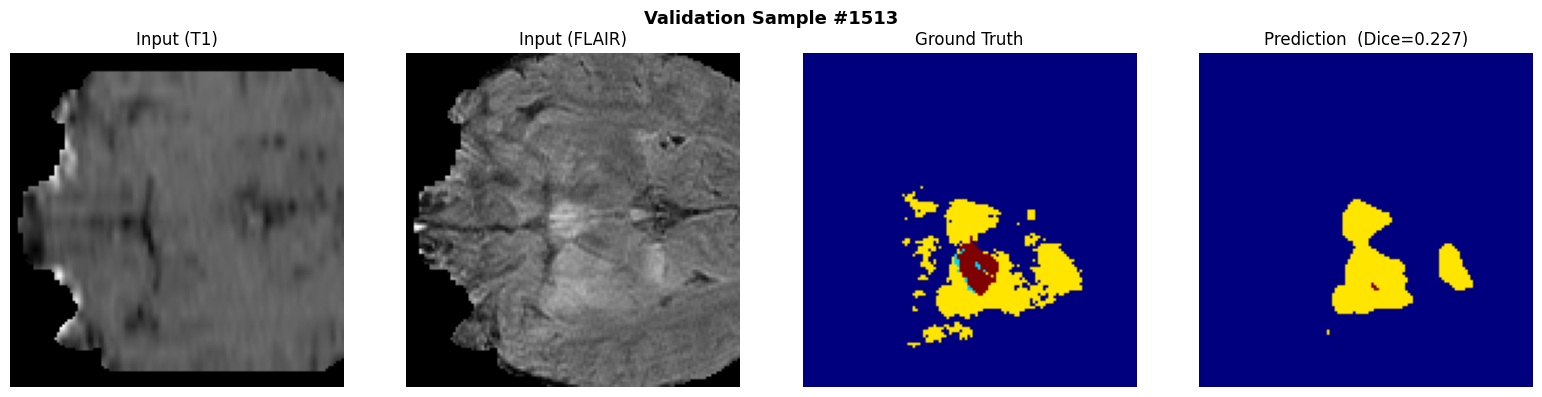

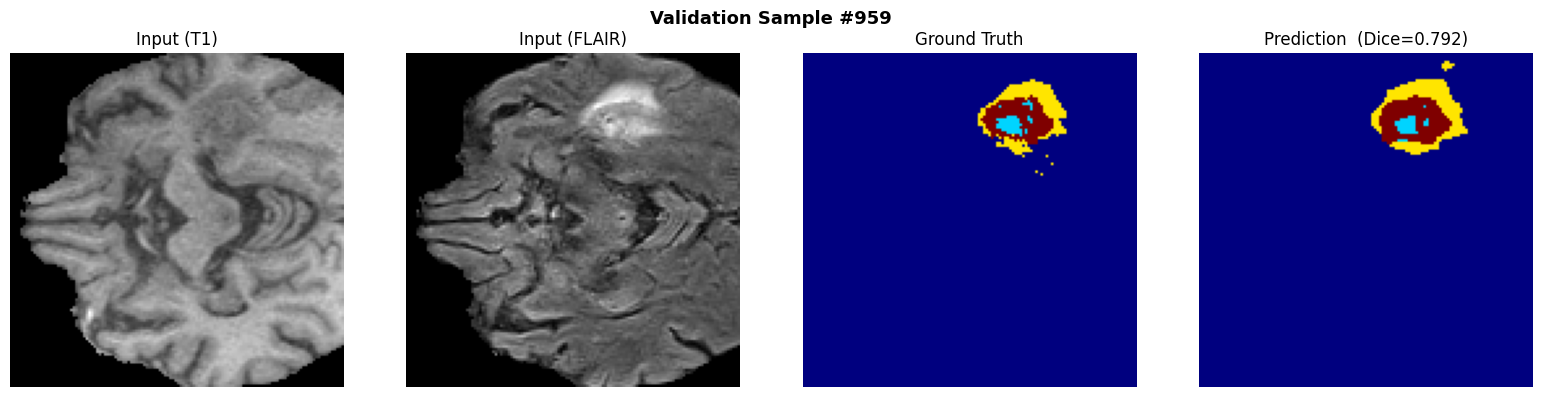

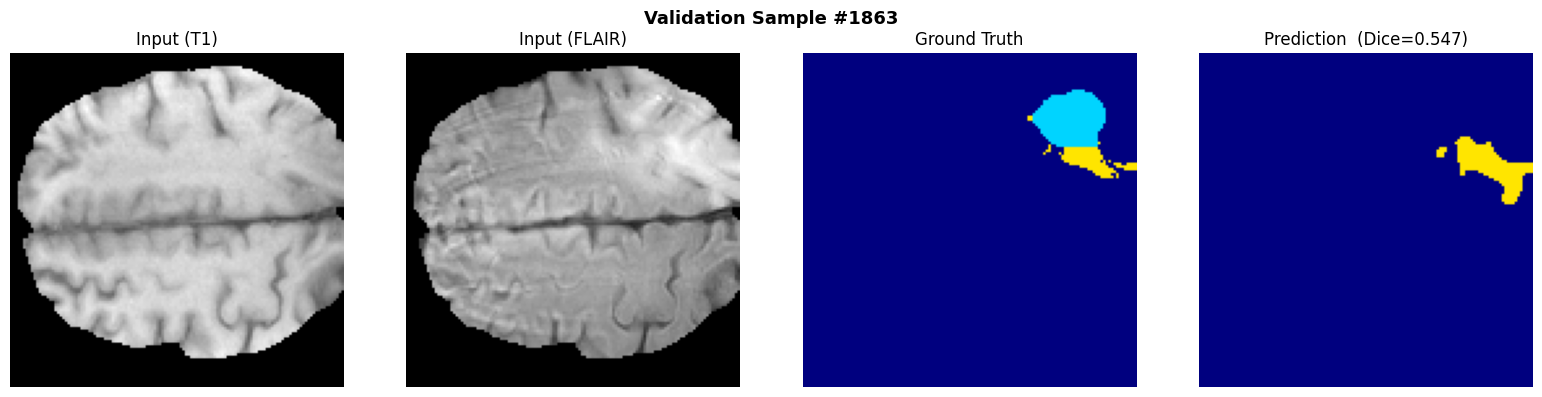

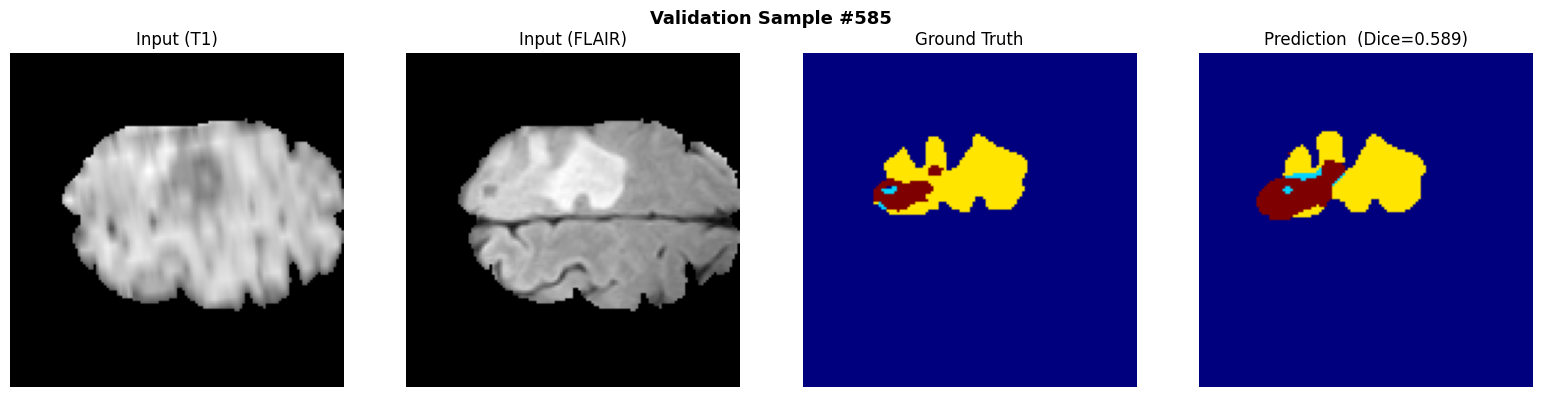

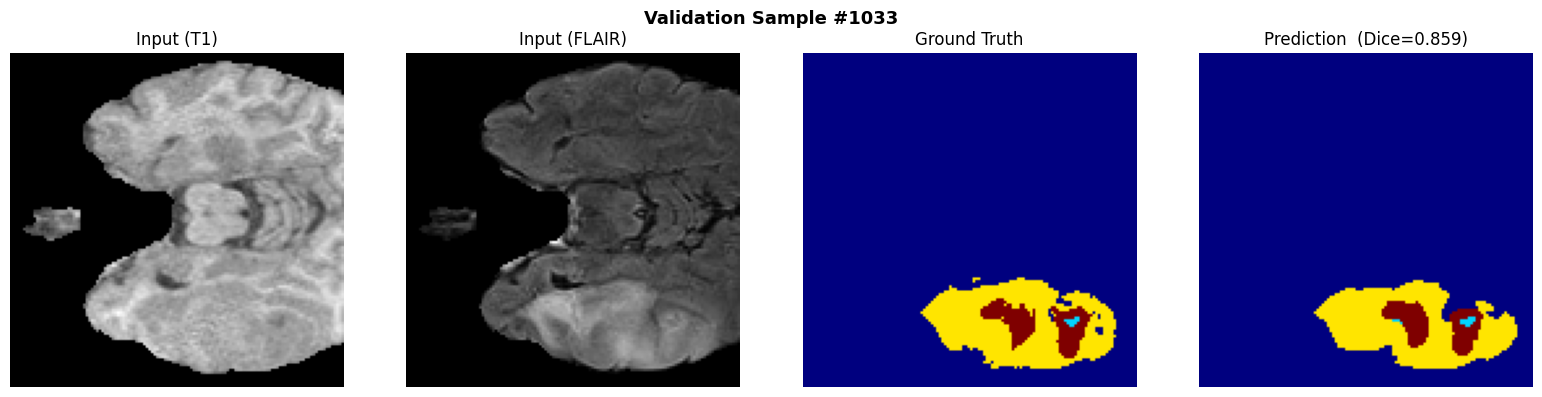

In [15]:
# Visualize Predictions
def visualize_prediction(X, Y_int, model, idx=0):
    """
    Show: FLAIR input | Ground Truth | Prediction | Overlay
    """
    pred  = model.predict(X[idx:idx+1], verbose=0)
    pred  = np.argmax(pred[0], axis=-1)
    true  = Y_int[idx]

    # Compute per-slice Dice for display
    dice_vals = []
    for cls in [1, 2, 3]:
        tp   = np.sum((true == cls) & (pred == cls))
        fp   = np.sum((true != cls) & (pred == cls))
        fn   = np.sum((true == cls) & (pred != cls))
        dice = (2 * tp + 1e-6) / (2 * tp + fp + fn + 1e-6)
        dice_vals.append(dice)
    slice_dice = np.mean(dice_vals)

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    axes[0].imshow(X[idx][:, :, 0], cmap='gray')
    axes[0].set_title('Input (T1)')
    axes[0].axis('off')

    axes[1].imshow(X[idx][:, :, 2], cmap='gray')
    axes[1].set_title('Input (FLAIR)')
    axes[1].axis('off')

    axes[2].imshow(true, cmap='jet', vmin=0, vmax=3)
    axes[2].set_title('Ground Truth')
    axes[2].axis('off')

    axes[3].imshow(pred, cmap='jet', vmin=0, vmax=3)
    axes[3].set_title(f'Prediction  (Dice={slice_dice:.3f})')
    axes[3].axis('off')

    plt.suptitle(f'Validation Sample #{idx}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'pred_sample_{idx}.png', dpi=150)
    plt.show()


# Visualize a few random slices that HAVE tumor (more informative)
tumor_indices = np.where(Y_val.sum(axis=(1, 2)) > 50)[0]
for idx in np.random.choice(tumor_indices, size=min(5, len(tumor_indices)), replace=False):
    visualize_prediction(X_val, Y_val, model, idx=int(idx))

